 # Navie Bayes Algorithm(As classifier ) with Manual DataSet 

### Importing Libraries

In [7]:
import pandas as pd
import numpy as np

### Assigning features and label variables

In [8]:
wheather=['Sunny','Sunny','Overcast','Rainy','Rainy','Rainy','Overcast','Sunny','Sunny',
'Rainy','Sunny','Overcast','Overcast','Rainy']
temp=['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild']

play=['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']

#### We need to convert features from string to integers for Probability Computations: 
```python
The Naive Bayes algorithm involves computing probabilities. Probability calculations are typically based on the frequency of events in the dataset. When the data is numerical, it's easier to compute probabilities and likelihoods.
```

### Feature Scaling to bring the variable in a single scale

#### Import LabelEncoder

In [ ]:
from sklearn import preprocessing

#### Creating label Encoder

In [ ]:
le = preprocessing.LabelEncoder()

```python 
we are using LabelEncoder because it is using tio convert string into numerical
StandardScalar is to Used for standardizing numerical features by removing the mean and scaling to unit variance
```

In [34]:
wheather_encoded=le.fit_transform(wheather)
temp_encoded=le.fit_transform(temp)
label=le.fit_transform(play)
print("Wheather:",wheather_encoded)
print("Temp:",temp_encoded)
print("Play:",label)

Wheather: [2 2 0 1 1 1 0 2 2 1 2 0 0 1]
Temp: [1 1 1 2 0 0 0 2 0 2 2 2 1 2]
Play: [0 0 1 1 1 0 1 0 1 1 1 1 1 0]


#### Converting Data set into Dataframe

In [35]:
df = pd.DataFrame({'wheather' :wheather_encoded,
             'temp'     :temp_encoded,
              'play'     : label})

In [36]:
df

,wheather,temp,play
0,2,1,0
1,2,1,0
2,0,1,1
3,1,2,1
4,1,0,1
5,1,0,0
6,0,0,1
7,2,2,0
8,2,0,1
9,1,2,1


#### Spliting the dataset in independent and dependent variables

In [38]:
X = df.iloc[:,:2]
y = df.iloc[:,-1]

#### Splitting the dataset into the Training set and Test set

In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.20,random_state=42)

#### Generating Model

Generate a model using naive bayes classifier in the following steps:

* Create naive bayes classifier
* Fit the dataset on classifier
* Perform prediction

### Import Gaussian Naive Bayes model

In [42]:
from sklearn.naive_bayes import GaussianNB

### Create a Gaussian Classifier

In [43]:
Navie_Bayes_model = GaussianNB()

### Train the model using the training sets

In [45]:
Navie_Bayes_model.fit(X_train, y_train)

GaussianNB()

In [46]:
y_predicted = Navie_Bayes_model.predict(X_test)

#### Comaprsion of Y_predicted & Y_test

In [49]:
com_data = pd.DataFrame({ "Actual Data" : y_test,
                           "Predicted Data" :y_predicted 
})
com_data

,Actual Data,Predicted Data
9,1,0
11,1,1
0,0,0


#### Accuracy Of Model

In [52]:
from sklearn.metrics import accuracy_score
Accuracy = accuracy_score(y_test,y_predicted)
print("Accuracy of the Model is  :- ", Accuracy*100)

Accuracy of the Model is  :-  66.66666666666666


#### Confusion Matrix

In [54]:
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_test,y_predicted)
matrix

array([[1, 0],
       [1, 1]])

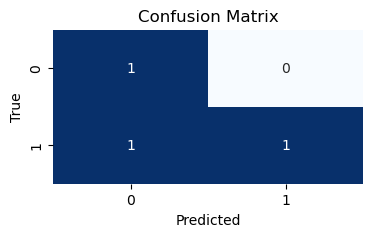

In [59]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_predicted)

# Plot confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


#### F1 Score

In [61]:
from sklearn.metrics import f1_score
score = f1_score(y_test,y_predicted)
score

0.6666666666666666

In [80]:
def predict_Data(arr):
    predicted= Navie_Bayes_model.predict([arr]) # 0:Overcast, 2:Mild
    if predicted == 1:
        return "Players Can Play"
    else:
        return "Players Can not play"

### Predict New Data

In [81]:
Wheather = int(input("Enter the value of Wheather :- "))
Temp = int(input("Enter the value of Temperature :- "))
arr = [Wheather,Temp]
data = predict_Data(arr)
print(data)

Enter the value of Wheather :-  0
Enter the value of Temperature :-  2


Players Can Play


/opt/conda/lib/python3.10/site-packages/sklearn/base.py:409: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


Here, 1 indicates that players can 'play'.